In [ ]:
import pandas as pd
from features import save_features, get_features
from productdata import get_productdata, convert_matlab_datenum
from marketdata import get_marketdata
from scipy.io import loadmat

product_data = get_productdata()
market_data = get_marketdata()
divs = loadmat(r"C:\Users\UGGROO\OneDrive - Van Lanschot Kempen\Documents\MSc Thesis\3. Repos\spil-utilities\spil-core\MainFiles\StoredMarketdataFiles\historicDiv_2025-07-12.mat")

features = get_features(product_data, market_data, divs)

save_features(features)

In [1]:
import pandas as pd

# Load DataFrame from pickle file
df = pd.read_pickle("feature_files/features_saved_on_2025-07-12.pkl")
df = df.dropna()

# Ensure Date is in datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Sort DataFrame by Date
df = df.sort_values(by='Date')

# Define target (y) and features (X)
y = df['Price']
X = df.drop(columns=['Price', 'Date'])  # Exclude Date from features

# Compute the split index (80% train, 20% test)
split_index = int(len(df) * 0.8)

# Perform time-based train-test split
X_train_val, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train_val, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Print shapes to verify
print(f"X_train shape: {X_train_val.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train_val.shape}, y_test shape: {y_test.shape}")

X_train shape: (71871, 41), X_test shape: (17968, 41)
y_train shape: (71871,), y_test shape: (17968,)


In [2]:
import optuna
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit             

def tune_xgboost(trainval_X, trainval_y, n_trials=50, random_state=42, n_splits=3):
    """
    Tune XGBoost using Optuna with time-series cross-validation.
    """
    X, y = trainval_X, trainval_y
    cv = TimeSeriesSplit(n_splits=n_splits)

    def objective(trial):
        params = {
            "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
            "max_depth":         trial.suggest_int("max_depth", 3, 10),
            "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma":             trial.suggest_float("gamma", 0.0, 5.0),
            "reg_alpha":         trial.suggest_float("reg_alpha", 0.0, 10.0),
            "reg_lambda":        trial.suggest_float("reg_lambda", 0.0, 10.0),
            "random_state":      random_state
        }

        mses = []
        for train_idx, valid_idx in cv.split(X):
            if hasattr(X, "iloc"):
                X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
                y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]
            else:
                X_train, X_valid = X[train_idx], X[valid_idx]
                y_train, y_valid = y[train_idx], y[valid_idx]

            model = XGBRegressor(**params, early_stopping_rounds=20)
            model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
            preds = model.predict(X_valid)
            mses.append(mean_squared_error(y_valid, preds))

        return float(np.mean(mses))

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    best_params = study.best_params

    best_model = XGBRegressor(**best_params)
    best_model.fit(trainval_X, trainval_y)

    return best_model, best_params

In [4]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_squared_error
import numpy as np
from xgboost import XGBRegressor
from scipy.stats import skew, kurtosis, jarque_bera    


def evaluate_xgboost_model_from_params(best_params, X_train_val, y_train_val,
                                       X_test, y_test, random_state=42):
    """
    Evaluate XGBoost model using given best parameters.
    """
    best_params = best_params.copy()
    best_params["random_state"] = random_state

    model = XGBRegressor(**best_params)
    model.fit(X_train_val, y_train_val)

    pred_in_sample = model.predict(X_train_val)

    in_sample_metrics = {
        "Average Absolute Error": mean_absolute_error(y_train_val, pred_in_sample),
        "Maximum Absolute Error": np.max(np.abs(y_train_val - pred_in_sample)),
        "MSE": mean_squared_error(y_train_val, pred_in_sample),
        "Root Mean Squared Error": root_mean_squared_error(y_train_val, pred_in_sample),
        "Adjusted MAPE (%)": np.mean(np.abs((y_train_val - pred_in_sample) / (max(y_train_val) - min(y_train_val)))) * 100,
        "Out of Sample R2": r2_score(y_train_val, pred_in_sample)}

    predictions = model.predict(X_test)

    avg_abs_error = mean_absolute_error(y_test, predictions)
    max_abs_error = np.max(np.abs(y_test - predictions))
    rmse = root_mean_squared_error(y_test, predictions)

    epsilon = 1e-8
    mape = np.mean(np.abs((y_test - predictions) / (y_test + epsilon))) * 100
    adjusted_mape = np.mean(np.abs((y_test - predictions) / (max(y_test) - min(y_test)))) * 100
    r2 = r2_score(y_test, predictions)
     
    # NEW error statistics
    errors = y_test - predictions
    mean_error = np.mean(errors)
    std_error = np.std(errors, ddof=1)
    skewness_error = skew(errors, bias=False)
    kurtosis_error = kurtosis(errors, fisher=False, bias=False)
    jb_stat, jb_p = jarque_bera(errors)

    out_sample_metrics = {
        "Average Absolute Error": avg_abs_error,
        "Maximum Absolute Error": max_abs_error,
        "Root Mean Squared Error": rmse,
        "Mean Absolute Percentage Error (%)": mape,
        "Adjusted MAPE (%)": adjusted_mape,
        "Out of Sample R2": r2,
        "Mean Error": mean_error,
        "Std Dev Error": std_error,
        "Skewness": skewness_error,
        "Kurtosis": kurtosis_error,
        "Jarque-Bera Statistic": jb_stat,
        "Jarque-Bera p-value": jb_p,
        "Pricing Errors": errors
    }

    return in_sample_metrics, out_sample_metrics

In [3]:
import pickle
from xgboost import XGBRegressor

def save_xgboost_model(best_params, X, y, save_path="trained_xgboost_model.pkl", random_state=42):
    """
    Trains an XGBoost model on the full dataset and saves it to disk.

    Parameters:
    best_params (dict): Tuned hyperparameters.
    X (DataFrame): Full feature set.
    y (Series): Full target set.
    save_path (str): Path to save the model.
    random_state (int): Random seed.

    Returns:
    None
    """
    best_params = best_params.copy()
    best_params["random_state"] = random_state

    model = XGBRegressor(**best_params)
    model.fit(X, y)

    with open(save_path, "wb") as f:
        pickle.dump(model, f)

    print(f"XGBoost model trained on full data and saved to {save_path}")

In [7]:
best_model, best_params = tune_xgboost(X_train_val, y_train_val, n_trials=200)
is_metrics, oos_metrics = evaluate_xgboost_model_from_params(best_params, X_train_val, y_train_val, X_test, y_test)

print("========== best params =============")
print(best_params)

print("========== in-sample =============")
print(is_metrics)

print("========== out-sample ============")
print(oos_metrics)

save_xgboost_model(best_params, X, y, save_path="models/xgb_full_model_NOT_retuned.pkl")

[I 2025-07-16 19:09:18,893] A new study created in memory with name: no-name-0451ee9a-7289-4c75-80d3-e49221b9a4c7
[I 2025-07-16 19:09:21,689] Trial 0 finished with value: 1.7882403634862802 and parameters: {'n_estimators': 693, 'max_depth': 5, 'learning_rate': 0.24630764459386095, 'subsample': 0.8372444963088465, 'colsample_bytree': 0.561882229778668, 'gamma': 0.9890125704536618, 'reg_alpha': 3.5852379460043684, 'reg_lambda': 5.396767914046533}. Best is trial 0 with value: 1.7882403634862802.
[I 2025-07-16 19:09:28,522] Trial 1 finished with value: 1.960962369471215 and parameters: {'n_estimators': 454, 'max_depth': 4, 'learning_rate': 0.054036175947598124, 'subsample': 0.5959319829551115, 'colsample_bytree': 0.7049090453778242, 'gamma': 2.6350746027197207, 'reg_alpha': 6.584934268294128, 'reg_lambda': 4.6125050165398385}. Best is trial 0 with value: 1.7882403634862802.
[I 2025-07-16 19:09:45,361] Trial 2 finished with value: 2.2868217124213515 and parameters: {'n_estimators': 567, 'ma

========== best params =============
{'n_estimators': 453, 'max_depth': 5, 'learning_rate': 0.07134994697864115, 'subsample': 0.6253375915260739, 'colsample_bytree': 0.5060021781526435, 'gamma': 0.11343275311876466, 'reg_alpha': 0.04545042246911753, 'reg_lambda': 3.4515018999088007}
========== in-sample =============
{'Average Absolute Error': 0.14016366501276728, 'Maximum Absolute Error': 4.849651401519775, 'MSE': 0.04969185415699085, 'Root Mean Squared Error': 0.2229166977976097, 'Adjusted MAPE (%)': 0.4095810262014758, 'Out of Sample R2': 0.9982974455142627}
========== out-sample ============
{'Average Absolute Error': 0.5408585087344753, 'Maximum Absolute Error': 5.3588995933532715, 'Root Mean Squared Error': 0.7998541853831891, 'Mean Absolute Percentage Error (%)': 879425511.6794931, 'Adjusted MAPE (%)': 2.138241445288824, 'Out of Sample R2': 0.9773107857539981, 'Mean Error': 0.12250018172636044, 'Std Dev Error': 0.7904398750153631, 'Skewness': -0.059704142329647686, 'Kurtosis': 6

In [5]:
best_params = {'n_estimators': 453, 'max_depth': 5, 'learning_rate': 0.07134994697864115, 'subsample': 0.6253375915260739, 'colsample_bytree': 0.5060021781526435, 'gamma': 0.11343275311876466, 'reg_alpha': 0.04545042246911753, 'reg_lambda': 3.4515018999088007}
is_metrics, oos_metrics = evaluate_xgboost_model_from_params(best_params, X_train_val, y_train_val, X_test, y_test)

print("========== in-sample =============")
print(is_metrics)

print("========== out-sample ============")
print(oos_metrics)

oos_metrics['Pricing Errors'].to_csv("errors/xgb_errors_not_retuned.csv", index = False)

========== in-sample =============
{'Average Absolute Error': 0.14016366501276728, 'Maximum Absolute Error': 4.849651401519775, 'MSE': 0.04969185415699085, 'Root Mean Squared Error': 0.2229166977976097, 'Adjusted MAPE (%)': 0.4095810262014758, 'Out of Sample R2': 0.9982974455142627}
========== out-sample ============
{'Average Absolute Error': 0.5408585087344753, 'Maximum Absolute Error': 5.3588995933532715, 'Root Mean Squared Error': 0.7998541853831891, 'Mean Absolute Percentage Error (%)': 879425511.6794931, 'Adjusted MAPE (%)': 2.138241445288824, 'Out of Sample R2': 0.9773107857539981, 'Mean Error': 0.12250018172636044, 'Std Dev Error': 0.7904398750153631, 'Skewness': -0.059704142329647686, 'Kurtosis': 6.798491544712792, 'Jarque-Bera Statistic': 10804.929306951264, 'Jarque-Bera p-value': 0.0, 'Pricing Errors': 84675   -0.086614
73825   -0.246579
69395   -0.421482
63475    0.303587
69394   -0.445864
           ...   
81351    0.318692
81352    0.330792
81353    0.284945
80396    0.66

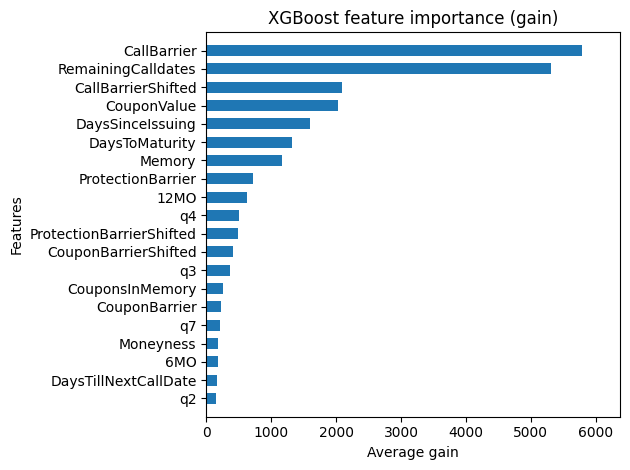

In [9]:
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd

model = pd.read_pickle("models/xgb_full_model_NOT_retuned.pkl")

# Built-in plot (defaults to F-score).  Other options: 'gain', 'weight', 'cover'
xgb.plot_importance(model,
                    importance_type='gain',   # or 'weight', 'cover'
                    max_num_features=20,      # top-20; omit for all
                    height=0.6,               # bar height
                    grid=False,
                    show_values=False,        # turn on if you want numbers on bars
                    xlabel='Average gain')

plt.title('XGBoost feature importance (gain)')
plt.tight_layout()
plt.show()

PermutationExplainer explainer: 301it [01:06,  3.78it/s]                         


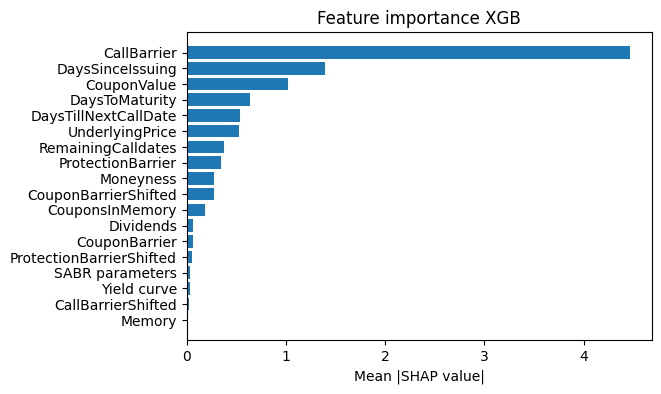

In [13]:
import shap
import pandas as pd

model = pd.read_pickle("models/xgb_full_model_retuned.pkl")  

# explainer = shap.Explainer(model.predict, X_train_val)  # background data
# shap_values = explainer(X_test.sample(400, random_state=42))                     # compute SHAP on test set


sim_df = pd.read_pickle(
    r"C:\Users\14gij\OneDrive\Documenten\1 Master\Thesis\thesis code\ML Training\feature_files\sim_features_large3_2025-07-21"
)
sim_df = sim_df.dropna()

# Define target (y) and features (X)
y_sim_test = sim_df['Price']
X_sim_test = sim_df.drop(columns=['Price', 'Date']) 

explainer = shap.Explainer(model.predict, X)  # background data
shap_values = explainer(X_sim_test.iloc[:300])     #.sample(400, random_state=42)
#shap.summary_plot(shap_values, X_test, plot_type = "bar", show= True)  # .iloc[:500]


import itertools
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Which columns belong to which logical group?
yield_cols = ['1BD', '1WK', '1MO', '2MO', '6MO', '12MO',
              '2YR', '3YR', '4YR', '5YR', '7YR']
sabr_cols  = ['AlphaA', 'AlphaB', 'AlphaC',
              'RhoA', 'RhoB', 'RhoC',
              'NuB',  'NuC']
div_cols   = ['q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7']

group_dict = {
    'Yield curve' : yield_cols,
    'SABR parameters'   : sabr_cols,
    'Dividends'   : div_cols,
}

all_cols = list(X_sim_test.columns)

# ----------------------------------------------------------------------
# 2. Aggregate SHAP values for the *defined* groups
group_importance = {}
for gname, gcols in group_dict.items():
    idx = [all_cols.index(c) for c in gcols]
    group_importance[gname] = np.abs(shap_values.values[:, idx]).mean()

# ----------------------------------------------------------------------
# 3. OPTIONAL: keep only features that are NOT in any group
#     (Skip this entire block if you do not want singletons at all.)
grouped_features = set(itertools.chain.from_iterable(group_dict.values()))

for c in all_cols:
    if c not in grouped_features:
        group_importance[c] = np.abs(
            shap_values.values[:, all_cols.index(c)]
        ).mean()

# ----------------------------------------------------------------------
# 4. Plot the result
group_importance = dict(
    sorted(group_importance.items(), key=lambda kv: kv[1], reverse=True)
)

plt.figure(figsize=(6, 4))
plt.barh(list(group_importance.keys()), list(group_importance.values()))
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP value|')
plt.title('Feature importance XGB')
plt.show()

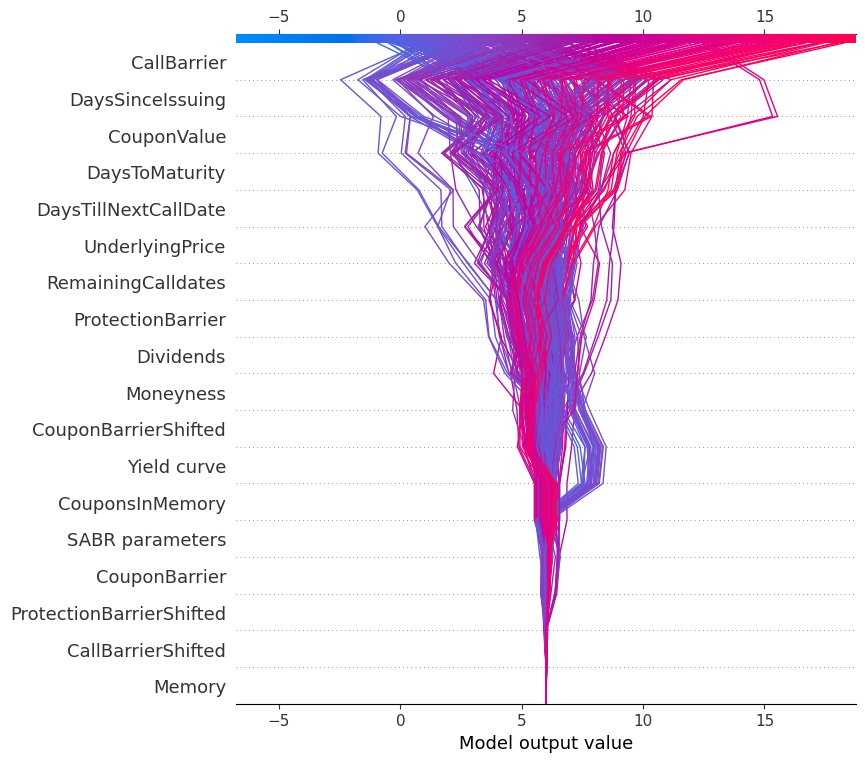

In [15]:
# --- SHAP decision plot with grouped features for a subsample of the first 200 observations ---
import numpy as np
import itertools

# 1) Build groups using your existing group_dict and add singletons
all_cols = list(X_sim_test.columns)
grouped_features = set(itertools.chain.from_iterable(group_dict.values()))

group_to_idx = {
    gname: [all_cols.index(c) for c in gcols if c in all_cols]
    for gname, gcols in group_dict.items()
}
for c in all_cols:
    if c not in grouped_features:
        group_to_idx[c] = [all_cols.index(c)]

group_names = list(group_to_idx.keys())

# 2) Aggregate SHAP values per group for ALL samples -> [n_samples x n_groups]
sv = shap_values.values  # shape: [n_samples x n_features]
group_sv_mat = np.column_stack([
    sv[:, idxs].sum(axis=1) if len(idxs) > 1 else sv[:, idxs[0]]
    for idxs in group_to_idx.values()
])

# 3) Order groups by global importance (mean |SHAP|) for cleaner plotting
order = np.argsort(np.mean(np.abs(group_sv_mat), axis=0))
group_sv_mat = group_sv_mat[:, order]
group_names_ordered = [group_names[j] for j in order]

# 4) Subsample the first 200 observations (avoid very large, slow plot)
idx = np.arange(min(200, group_sv_mat.shape[0]))

# 5) Use a scalar base value (average of base values across samples)
base_value_scalar = float(np.mean(shap_values.base_values))

# 6) Decision plot showing grouped paths for the subsample
shap.decision_plot(
    base_value=base_value_scalar,
    shap_values=group_sv_mat,  #[idx, :]
    feature_names=group_names_ordered,
    link="identity",
    show=True
)


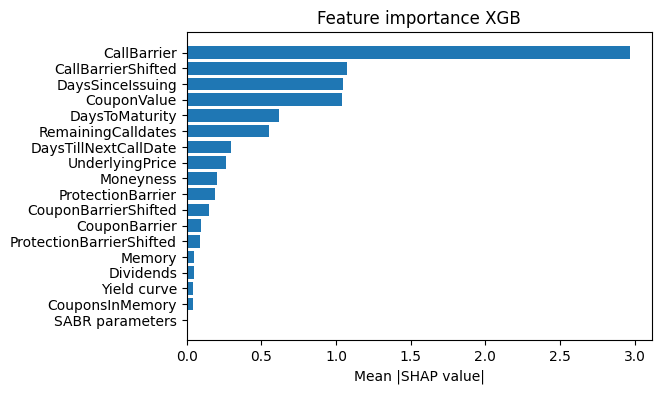

In [7]:

import itertools
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# 1. Which columns belong to which logical group?
yield_cols = ['1BD', '1WK', '1MO', '2MO', '6MO', '12MO',
              '2YR', '3YR', '4YR', '5YR', '7YR']
sabr_cols  = ['AlphaA', 'AlphaB', 'AlphaC',
              'RhoA', 'RhoB', 'RhoC',
              'NuB',  'NuC']
div_cols   = ['q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q7']

group_dict = {
    'Yield curve' : yield_cols,
    'SABR parameters'   : sabr_cols,
    'Dividends'   : div_cols,
}

all_cols = list(X_test.columns)

# ----------------------------------------------------------------------
# 2. Aggregate SHAP values for the *defined* groups
group_importance = {}
for gname, gcols in group_dict.items():
    idx = [all_cols.index(c) for c in gcols]
    group_importance[gname] = np.abs(shap_values.values[:, idx]).mean()

# ----------------------------------------------------------------------
# 3. OPTIONAL: keep only features that are NOT in any group
#     (Skip this entire block if you do not want singletons at all.)
grouped_features = set(itertools.chain.from_iterable(group_dict.values()))

for c in all_cols:
    if c not in grouped_features:
        group_importance[c] = np.abs(
            shap_values.values[:, all_cols.index(c)]
        ).mean()

# ----------------------------------------------------------------------
# 4. Plot the result
group_importance = dict(
    sorted(group_importance.items(), key=lambda kv: kv[1], reverse=True)
)

plt.figure(figsize=(6, 4))
plt.barh(list(group_importance.keys()), list(group_importance.values()))
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP value|')
plt.title('Feature importance XGB')
plt.show()

In [ ]:
best_params = {'n_estimators': 453, 'max_depth': 5, 'learning_rate': 0.07134994697864115, 'subsample': 0.6253375915260739, 'colsample_bytree': 0.5060021781526435, 'gamma': 0.11343275311876466, 'reg_alpha': 0.04545042246911753, 'reg_lambda': 3.4515018999088007}

df_test = X_test.copy()             
df_test["target"] = y_test

mask_lt50 = df_test['DaysTillNextCallDate'] < 50
mask_ge50 = ~mask_lt50              

test_lt50 = df_test[mask_lt50].reset_index(drop=True)
test_ge50 = df_test[mask_ge50].reset_index(drop=True)

X_test_lt50, y_test_lt50 = test_lt50.drop(columns="target"), test_lt50["target"]
X_test_ge50, y_test_ge50 = test_ge50.drop(columns="target"), test_ge50["target"]

print(f"< 50 days : {len(X_test_lt50)} samples")
print(f"≥ 50 days: {len(X_test_ge50)} samples")

is_metrics_lt50, oos_metrics_lt50 = evaluate_xgboost_model_from_params(best_params, X_train_val, y_train_val, X_test_lt50, y_test_lt50)
is_metrics_ge50, oos_metrics_ge50 = evaluate_xgboost_model_from_params(best_params, X_train_val, y_train_val, X_test_ge50, y_test_ge50)

# print("========== in-sample lt 50 =============")
# print(is_metrics_lt50)

print("========== out-sample lt 50 ============")
print(oos_metrics_lt50)


# print("========== in-sample ge 50 =============")
# print(is_metrics_ge50)

print("========== out-sample ge 50 ============")
print(oos_metrics_ge50)

< 50 days : 2303 samples
≥ 50 days: 15665 samples
========== out-sample lt 50 ============
{'Average Absolute Error': 0.42430912001968885, 'Maximum Absolute Error': 2.9586499981689443, 'Root Mean Squared Error': 0.7183895029053232, 'Mean Absolute Percentage Error (%)': 1412481466.1160114, 'Adjusted MAPE (%)': 2.3912710508606665, 'Out of Sample R2': 0.9817119674117825, 'Mean Error': 0.019285112178672185, 'Std Dev Error': 0.7182865653376791, 'Skewness': 1.408554924630149, 'Kurtosis': 8.613264751920479, 'Jarque-Bera Statistic': 3768.1650005474294, 'Jarque-Bera p-value': 0.0, 'Pricing Errors': 0      -0.421482
1      -0.445864
2       0.231197
3       0.249124
4       0.342058
          ...   
2298   -0.174553
2299   -0.175118
2300    0.336190
2301    0.324743
2302    0.337884
Name: target, Length: 2303, dtype: float64}
========== out-sample ge 50 ============
{'Average Absolute Error': 0.5579930917035243, 'Maximum Absolute Error': 5.3588995933532715, 'Root Mean Squared Error': 0.811141226

In [14]:
best_params = {'n_estimators': 453, 'max_depth': 5, 'learning_rate': 0.07134994697864115, 'subsample': 0.6253375915260739, 'colsample_bytree': 0.5060021781526435, 'gamma': 0.11343275311876466, 'reg_alpha': 0.04545042246911753, 'reg_lambda': 3.4515018999088007}

df_test = X_test.copy()
df_test["target"] = y_test                    


mask_edge = (
    (df_test["DaysTillNextCallDate"] < 25)
    | ((df_test["DaysTillNextCallDate"] >= 340)
       & (df_test["DaysTillNextCallDate"] <= 365))
)

mask_other = ~mask_edge                       

# split the test frame
test_edge  = df_test[mask_edge].reset_index(drop=True)
test_other = df_test[mask_other].reset_index(drop=True)

# split into X / y
X_test_edge,  y_test_edge  = test_edge.drop(columns="target"),  test_edge["target"]
X_test_other, y_test_other = test_other.drop(columns="target"), test_other["target"]

print(f"Edge-of-year (<20  or  340–365) : {len(X_test_edge)} samples")
print(f"Other                            : {len(X_test_other)} samples")


is_metrics_edge,  oos_metrics_edge  = evaluate_xgboost_model_from_params(
                                        best_params,
                                        X_train_val, y_train_val,
                                        X_test_edge,  y_test_edge)

is_metrics_other, oos_metrics_other = evaluate_xgboost_model_from_params(
                                        best_params,
                                        X_train_val, y_train_val,
                                        X_test_other, y_test_other)

print("\n========== out-sample  (edge-of-year) ==========")
print(oos_metrics_edge)

print("\n========== out-sample  (other) ================")
print(oos_metrics_other)

Edge-of-year (<20  or  340–365) : 2669 samples
Other                            : 15299 samples

========== out-sample  (edge-of-year) ==========
{'Average Absolute Error': 0.769754876893014, 'Maximum Absolute Error': 5.3588995933532715, 'Root Mean Squared Error': 1.1405708300217554, 'Mean Absolute Percentage Error (%)': 2120725517.9293303, 'Adjusted MAPE (%)': 4.3380933063321105, 'Out of Sample R2': 0.942726502925062, 'Mean Error': -0.3694709781291477, 'Std Dev Error': 1.0792726457122432, 'Skewness': 0.10822511809058057, 'Kurtosis': 5.810032027134639, 'Jarque-Bera Statistic': 878.6498595619286, 'Jarque-Bera p-value': 1.5981120773499833e-191, 'Pricing Errors': 0      -0.421482
1      -0.445864
2       0.231197
3       0.249124
4       0.342058
          ...   
2664   -1.781409
2665   -1.778314
2666   -1.353783
2667   -1.346479
2668   -0.926744
Name: target, Length: 2669, dtype: float64}

========== out-sample  (other) ================
{'Average Absolute Error': 0.5009261990008234, 'Max

In [13]:
best_params = {'n_estimators': 453, 'max_depth': 5, 'learning_rate': 0.07134994697864115, 'subsample': 0.6253375915260739, 'colsample_bytree': 0.5060021781526435, 'gamma': 0.11343275311876466, 'reg_alpha': 0.04545042246911753, 'reg_lambda': 3.4515018999088007}


df_test = X_test.copy()
df_test["target"] = y_test


delta        = (df_test["Moneyness"] * 100 - df_test["CouponBarrier"]).abs()
diff_ratio   = delta / df_test["CouponBarrier"]

mask_within5pct  = diff_ratio <= 0.10       # ≤ 5 %
mask_outside5pct = ~mask_within5pct         # > 5 %


test_within5pct  = df_test[mask_within5pct].reset_index(drop=True)
test_outside5pct = df_test[mask_outside5pct].reset_index(drop=True)

X_test_within5pct,  y_test_within5pct  = (
    test_within5pct.drop(columns="target"),  test_within5pct["target"]
)
X_test_outside5pct, y_test_outside5pct = (
    test_outside5pct.drop(columns="target"), test_outside5pct["target"]
)

print(f"Within 5 % of barrier : {len(X_test_within5pct)} samples")
print(f"Outside that range    : {len(X_test_outside5pct)} samples")


is_met_within5pct,  oos_met_within5pct = evaluate_xgboost_model_from_params(
    best_params,
    X_train_val, y_train_val,
    X_test_within5pct,  y_test_within5pct
)

is_met_outside5pct, oos_met_outside5pct = evaluate_xgboost_model_from_params(
    best_params,
    X_train_val, y_train_val,
    X_test_outside5pct, y_test_outside5pct
)

print("\n========== out-sample  |Δ|/Barrier ≤ 5 % ==========")
print(oos_met_within5pct)

print("\n========== out-sample  |Δ|/Barrier > 5 % ==========")
print(oos_met_outside5pct)

Within 5 % of barrier : 816 samples
Outside that range    : 17152 samples

========== out-sample  |Δ|/Barrier ≤ 5 % ==========
{'Average Absolute Error': 0.7837256765797457, 'Maximum Absolute Error': 3.807578212768555, 'Root Mean Squared Error': 1.0681589195972518, 'Mean Absolute Percentage Error (%)': 65.45154795087323, 'Adjusted MAPE (%)': 7.577628276958177, 'Out of Sample R2': 0.7763074795679527, 'Mean Error': -0.1503321866900462, 'Std Dev Error': 1.0581757588286662, 'Skewness': -1.2235118726339087, 'Kurtosis': 3.8732312041237016, 'Jarque-Bera Statistic': 228.0195984108294, 'Jarque-Bera p-value': 3.0631856737737564e-50, 'Pricing Errors': 0      0.303587
1      0.282685
2      0.269017
3      0.098043
4      0.476873
         ...   
811   -2.214421
812    1.543016
813    1.549172
814    1.538930
815    0.648429
Name: target, Length: 816, dtype: float64}

========== out-sample  |Δ|/Barrier > 5 % ==========
{'Average Absolute Error': 0.5293041938463141, 'Maximum Absolute Error': 5.3588

In [6]:
best_model_retuned, best_params_retuned = tune_xgboost(X, y, n_trials=300)

print("========== best params retuned =============")
print(best_params_retuned)

save_xgboost_model(best_params_retuned, X, y, save_path="models/xgb_full_model_retuned.pkl")

[I 2025-07-17 20:59:16,968] A new study created in memory with name: no-name-b9cc29ce-ca36-4b47-96cc-42882c79b968
[I 2025-07-17 20:59:20,318] Trial 0 finished with value: 2.6114819382857877 and parameters: {'n_estimators': 679, 'max_depth': 10, 'learning_rate': 0.1300854470308316, 'subsample': 0.7744570188005465, 'colsample_bytree': 0.6013392275008262, 'gamma': 3.4160896463299824, 'reg_alpha': 2.784887418010639, 'reg_lambda': 7.775780848191479}. Best is trial 0 with value: 2.6114819382857877.
[I 2025-07-17 20:59:24,241] Trial 1 finished with value: 2.295168712704249 and parameters: {'n_estimators': 333, 'max_depth': 5, 'learning_rate': 0.23339864770354807, 'subsample': 0.5223128198255425, 'colsample_bytree': 0.5881709848562902, 'gamma': 4.204981044877948, 'reg_alpha': 8.601601716541984, 'reg_lambda': 2.980908130885217}. Best is trial 1 with value: 2.295168712704249.
[I 2025-07-17 20:59:32,693] Trial 2 finished with value: 2.4230240302225234 and parameters: {'n_estimators': 901, 'max_de

========== best params retuned =============
{'n_estimators': 894, 'max_depth': 3, 'learning_rate': 0.22302134583482355, 'subsample': 0.532507844214872, 'colsample_bytree': 0.925161504078223, 'gamma': 0.4136227641826986, 'reg_alpha': 0.23107522522745066, 'reg_lambda': 8.089230480906368}
XGBoost model trained on full data and saved to models/xgb_full_model_retuned.pkl


In [6]:
import pandas as pd

best_params_experiment = {'n_estimators': 894, 'max_depth': 3, 'learning_rate': 0.22302134583482355, 'subsample': 0.532507844214872, 'colsample_bytree': 0.925161504078223, 'gamma': 0.4136227641826986, 'reg_alpha': 0.23107522522745066, 'reg_lambda': 8.089230480906368}

sim_train = pd.read_pickle(
    "C:/Users/UGGROO/OneDrive - Van Lanschot Kempen/Documents/MSc Thesis/3. Repos/thesis code/ML Training/feature_files/sim_features_large5_2025-07-22"
)
sim_train = sim_train.dropna()

y_sim_train = sim_train['Price']
X_sim_train = sim_train.drop(columns=['Price', 'Date']) 

save_xgboost_model(best_params_experiment, X_sim_train, y_sim_train, save_path="models/xgb_full_model_experiment_large4.pkl")


XGBoost model trained on full data and saved to models/xgb_full_model_experiment_large4.pkl


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from scipy.stats import skew, kurtosis, jarque_bera    

sim_df = pd.read_pickle(
    r"C:\Users\14gij\OneDrive\Documenten\1 Master\Thesis\thesis code\ML Training\feature_files\sim_features_large3_2025-07-21"
)
sim_df = sim_df.dropna()

#sim_df = sim_df[sim_df['CouponsInMemory']<=1]
#sim_df = sim_df[sim_df['CallBarrier']==1000]
#sim_df = sim_df[sim_df['CouponValue']==4.8]
#sim_df = sim_df[sim_df['Price']<=]

# Define target (y) and features (X)
y_sim_test = sim_df['Price']
X_sim_test = sim_df.drop(columns=['Price', 'Date'])  

model = pd.read_pickle("models/xgb_full_model_retuned.pkl")  

predictions = model.predict(X_sim_test)

avg_abs_error = mean_absolute_error(y_sim_test, predictions)
max_abs_error = np.max(np.abs(y_sim_test - predictions))
rmse = root_mean_squared_error(y_sim_test, predictions)

epsilon = 1e-8
mape = np.mean(np.abs((y_sim_test - predictions) / (y_sim_test + epsilon))) * 100
adjusted_mape = np.mean(np.abs((y_sim_test - predictions) / (max(y_sim_test) - min(y_sim_test)))) * 100
r2 = r2_score(y_sim_test, predictions)

errors = y_sim_test - predictions
errors.to_csv("errors/xgb_errors_retuned.csv", index = False)

mean_error = np.mean(errors)
std_error = np.std(errors, ddof=1)
skewness_error = skew(errors, bias=False)
kurtosis_error = kurtosis(errors, fisher=False, bias=False)
jb_stat, jb_p = jarque_bera(errors)

print({
        "Out of Sample R2": r2,
        "Root Mean Squared Error": rmse,
        "Adjusted MAPE (%)": adjusted_mape,
        "Mean Absolute Percentage Error (%)": mape,
        "Average Absolute Error": avg_abs_error,
        "Maximum Absolute Error": max_abs_error,
        "Mean Error": mean_error,
        "Std Dev Error": std_error,
        "Skewness": skewness_error,
        "Kurtosis": kurtosis_error,
        "Jarque-Bera Statistic": jb_stat,
        "Jarque-Bera p-value": jb_p
    })

{'Out of Sample R2': -0.18017339922172404, 'Root Mean Squared Error': 5.093793581433662, 'Adjusted MAPE (%)': 6.6536350784943465, 'Mean Absolute Percentage Error (%)': 42.15150728479157, 'Average Absolute Error': 2.9668884877780166, 'Maximum Absolute Error': 35.91757856163567, 'Mean Error': 1.5360510220424188, 'Std Dev Error': 4.857622637653866, 'Skewness': 2.4605504943819025, 'Kurtosis': 12.434945760409583, 'Jarque-Bera Statistic': 12033.679496892535, 'Jarque-Bera p-value': 0.0}


In [ ]:

# from sklearn.metrics import mean_absolute_error, root_mean_squared_error
# import numpy as np
# from xgboost import XGBRegressor

# def evaluate_xgboost_model_from_params(best_params, X_train_val, y_train_val, X_test, y_test, random_state=42):
#     """
#     Evaluate XGBoost model using given best parameters.

#     Parameters:
#     best_params (dict): Best XGBoost parameters from tuning.
#     X_train_val (DataFrame): Training + validation features.
#     y_train_val (Series): Training + validation targets.
#     X_test (DataFrame): Test features.
#     y_test (Series): Test targets.
#     random_state (int): Seed for reproducibility.

#     Returns:
#     dict: Evaluation metrics.
#     """
#     best_params = best_params.copy()
#     best_params["random_state"] = random_state

#     model = XGBRegressor(**best_params)
#     model.fit(X_train_val, y_train_val)
#     predictions = model.predict(X_test)

#     avg_abs_error = mean_absolute_error(y_test, predictions)
#     max_abs_error = np.max(np.abs(y_test - predictions))
#     rmse = root_mean_squared_error(y_test, predictions)

#     epsilon = 1e-8
#     mape = np.mean(np.abs((y_test - predictions) / (y_test + epsilon))) * 100
#     y_test_safe = np.where(np.abs(y_test) < 1e-2, 1e-2, y_test)
#     adjusted_mape = np.mean(np.abs((y_test - predictions) / y_test_safe)) * 100

#     return {
#         "Average Absolute Error": avg_abs_error,
#         "Maximum Absolute Error": max_abs_error,
#         "Root Mean Squared Error": rmse,
#         "Mean Absolute Percentage Error (%)": mape,
#         "Adjusted MAPE (%)": adjusted_mape
#     }


# sim_df = pd.read_pickle("C:/Users/UGGROO/OneDrive - Van Lanschot Kempen/Documents/MSc Thesis/3. Repos/thesis code/ML Training/feature_files/sim_features_2025-06-11")

# # Define target (y) and features (X)
# y_sim_test = sim_df['Price']
# X_sim_test = sim_df.drop(columns=['Price', 'Date'])  # Exclude Date from features

# model = pd.read_pickle("models/xgb_full_model.pkl")

# predictions = model.predict(X_sim_test)

# avg_abs_error = mean_absolute_error(y_sim_test, predictions)
# max_abs_error = np.max(np.abs(y_sim_test - predictions))
# rmse = root_mean_squared_error(y_sim_test, predictions)

# epsilon = 1e-8
# mape = np.mean(np.abs((y_sim_test - predictions) / (y_sim_test + epsilon))) * 100
# y_test_safe = np.where(np.abs(y_sim_test) < 1e-2, 1e-2, y_sim_test)
# adjusted_mape = np.mean(np.abs((y_sim_test - predictions) / y_test_safe)) * 100

# print({
#         "Average Absolute Error": avg_abs_error,
#         "Maximum Absolute Error": max_abs_error,
#         "Root Mean Squared Error": rmse,
#         "Mean Absolute Percentage Error (%)": mape,
#         "Adjusted MAPE (%)": adjusted_mape
#     })



# import optuna
# from xgboost import XGBRegressor
# from sklearn.metrics import mean_squared_error
# from sklearn.model_selection import train_test_split

# def tune_xgboost(trainval_X, trainval_y, n_trials=50, valid_size=0.2, random_state=42):
#     """
#     Tune XGBoost using Optuna with a time-aware split.

#     Parameters:
#         trainval_X (DataFrame): Features, ordered in time if time series.
#         trainval_y (Series): Targets.
#         n_trials (int): Number of Optuna trials.
#         valid_size (float): Fraction of data for validation.
#         random_state (int): Seed.

#     Returns:
#         best_model (XGBRegressor): Trained XGBoost model.
#         best_params (dict): Best hyperparameters found by Optuna.
#     """
#     n_samples = len(trainval_X)
#     split_index = int(n_samples * (1 - valid_size))

#     X_train, X_valid = trainval_X[:split_index], trainval_X[split_index:]
#     y_train, y_valid = trainval_y[:split_index], trainval_y[split_index:]

#     def objective(trial):
#         params = {
#             "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
#             "max_depth": trial.suggest_int("max_depth", 3, 10),
#             "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
#             "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#             "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#             "gamma": trial.suggest_float("gamma", 0, 5.0),
#             "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0),
#             "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0),
#             "random_state": random_state
#         }

#         model = XGBRegressor(**params, early_stopping_rounds=20)
#         model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
#         preds = model.predict(X_valid)
#         mse = mean_squared_error(y_valid, preds)
#         return mse

#     study = optuna.create_study(direction="minimize")
#     study.optimize(objective, n_trials=n_trials)

#     best_params = study.best_params

#     # Final model trained on full train+val data
#     best_model = XGBRegressor(**best_params)
#     best_model.fit(trainval_X, trainval_y)

#     return best_model, best_params